SUPPORT VECTOR MACHINE

Task 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df=pd.read_csv("Pharma_Industry.csv") # Loading the dataset

In [4]:
df.shape

(500, 6)

In [5]:
df.info

<bound method DataFrame.info of      Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0           -0.128538                        0.303280         -1.881849   
1           -1.846188                        2.865142         -0.929511   
2           -1.252393                       -1.541613          0.363632   
3            1.992515                       -1.142779         -0.766657   
4            0.377100                        0.538410         -0.029263   
..                ...                             ...               ...   
495         -1.553759                        0.506938          0.817890   
496          0.551476                        1.714321          0.340589   
497         -1.072743                       -0.221137          0.239247   
498          1.661259                        0.245759         -0.457096   
499         -1.143726                        0.715320          0.108560   

     Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug 

In [7]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [8]:
# Check missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [9]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

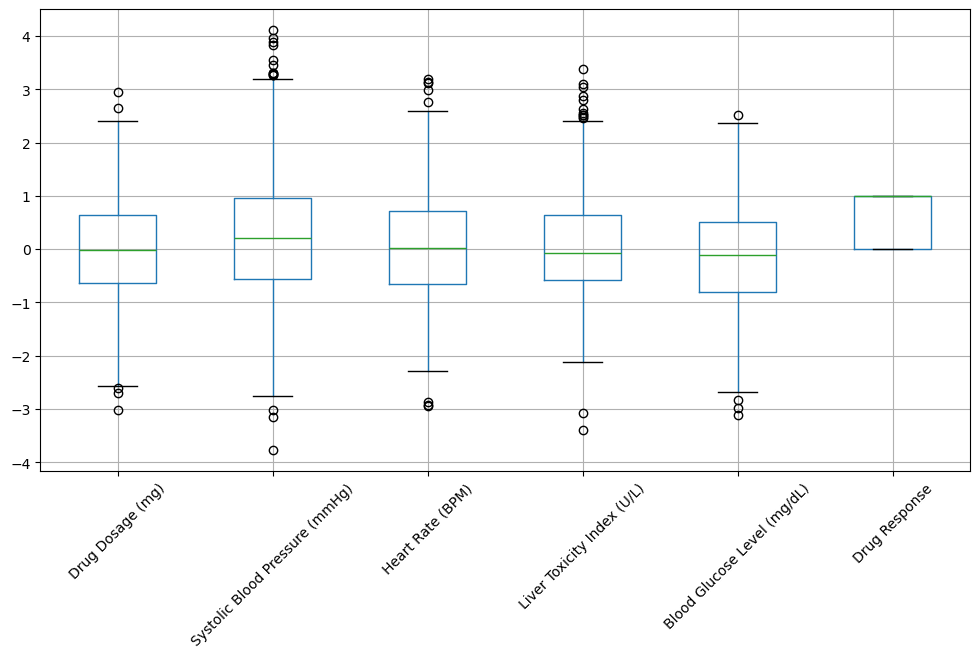

In [3]:
# checking for outliers
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [4]:
# Outlier treatment using IQR capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25) # calculating Q1
    Q3= df[columns].quantile(0.75) # calculating Q3
    IQR= Q3-Q1 # calculating IQR
    lower_extreme= Q1-1.5*IQR # calculating Lower_extreme
    upper_extreme= Q3+1.5*IQR # calculating upper extreme
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
# replacing values less than lower_extreme with lower_extreme and values greater than upper_extreme with upper_extreme
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

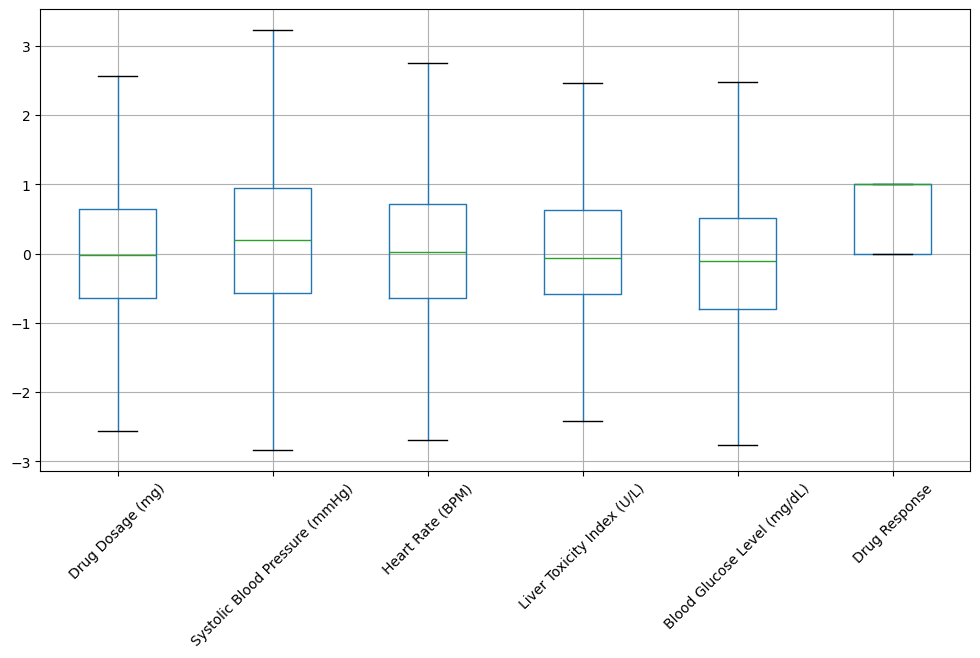

In [5]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()# shows outliers are treated

In [17]:
df.describe() # statistical summary

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037431,0.210298,0.061340,0.051165,-0.170695,0.5200
std,0.973785,1.219399,0.959388,0.958101,0.980097,0.5001
min,-2.566733,-2.839982,-2.686554,-2.416083,-2.764620,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.565881,3.226189,2.749171,2.463913,2.480460,1.0000


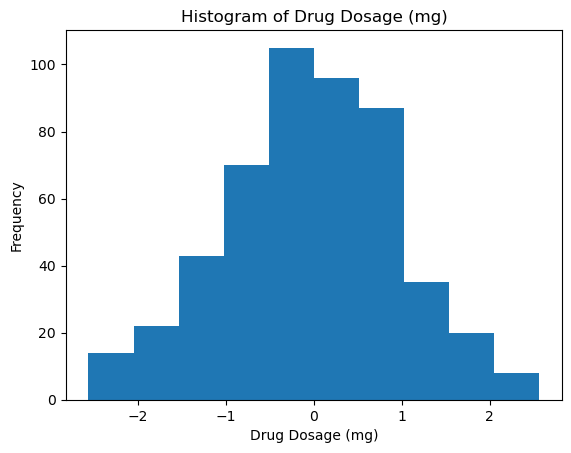

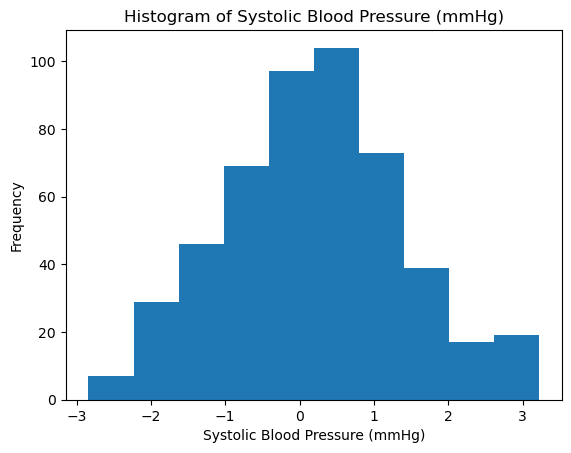

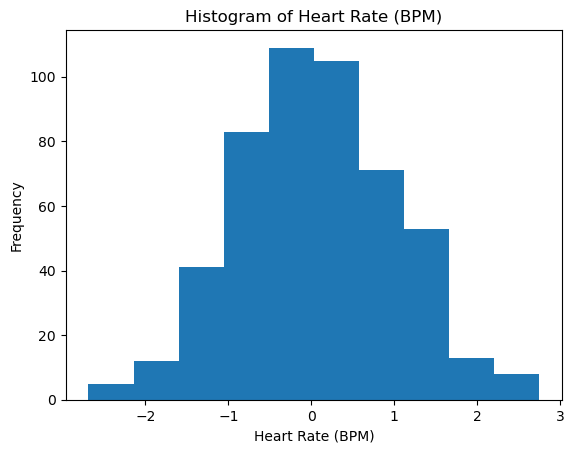

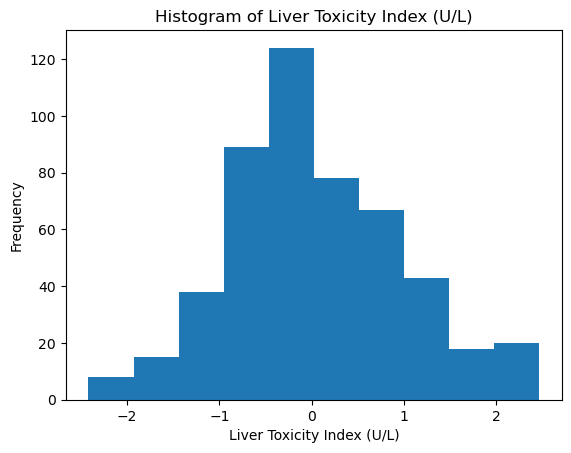

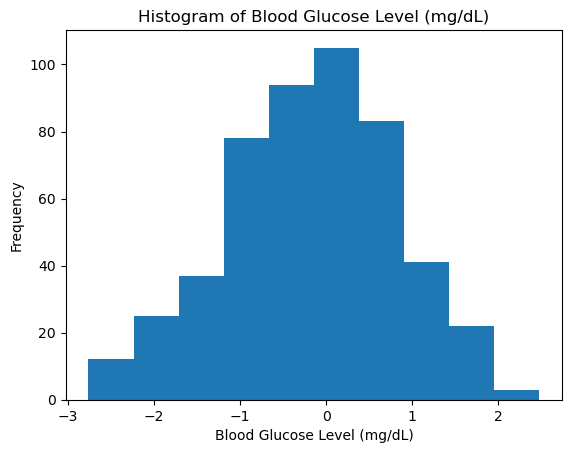

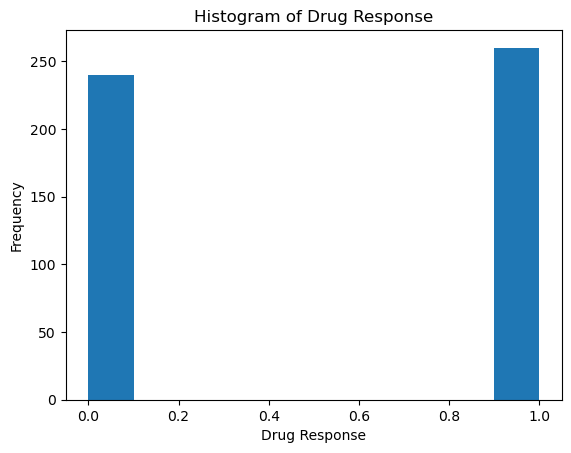

In [19]:
# Histogram
for col in df.columns: # refering to numerical columns
    plt.figure()
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()

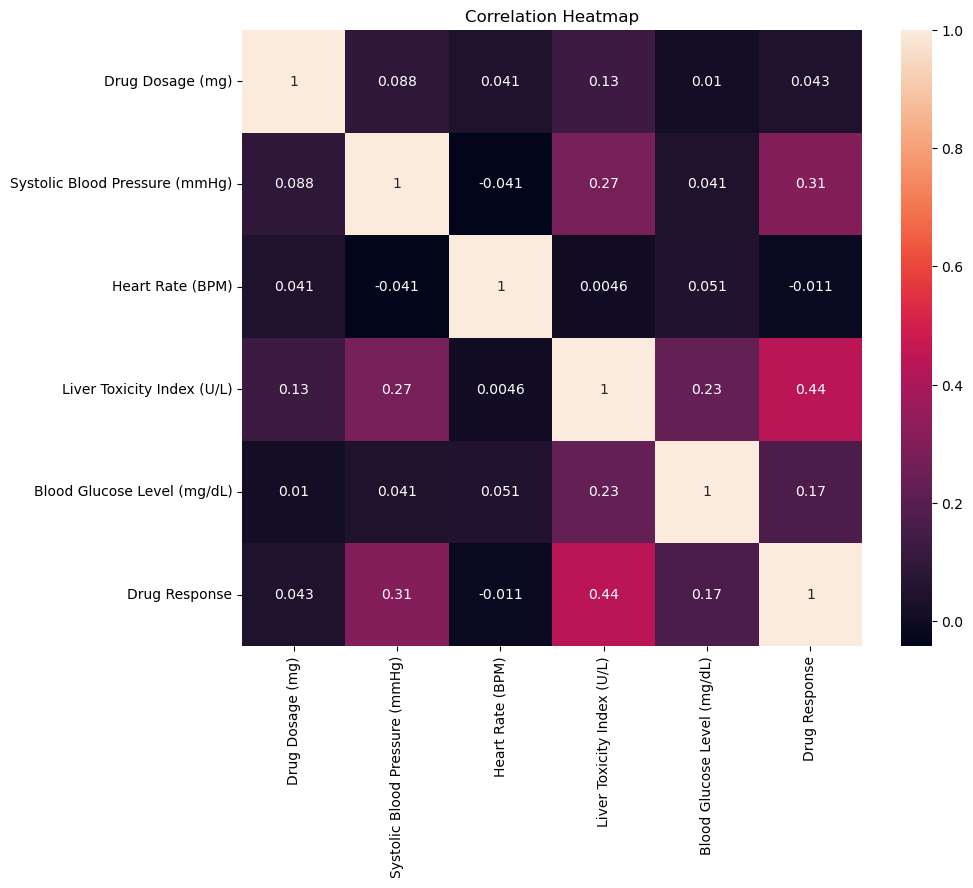

In [22]:
# Correlation heatmaps
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [6]:
#Feature & Target Separation
features= df.drop(columns=['Drug Response'])
target= df[['Drug Response']]

In [7]:
# Splitting the dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=150,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400, 1)
(100, 1)


In [8]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

In [9]:
std_sca=StandardScaler()
X_train_scaled = std_sca.fit_transform(x_train)
X_test_scaled = std_sca.transform(x_test)

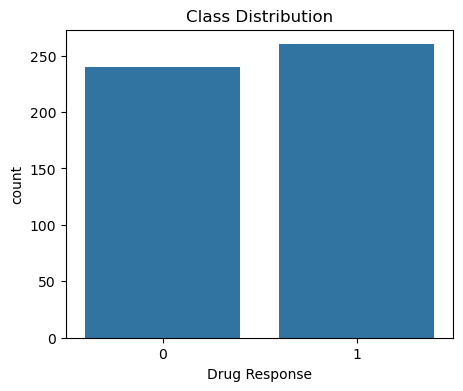

In [29]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["Drug Response"])
plt.title("Class Distribution")
plt.show()

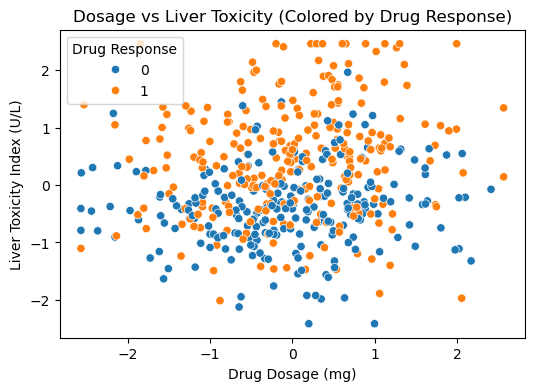

In [53]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Drug Dosage (mg)", y="Liver Toxicity Index (U/L)",hue="Drug Response")
plt.title("Dosage vs Liver Toxicity (Colored by Drug Response)")
plt.show()

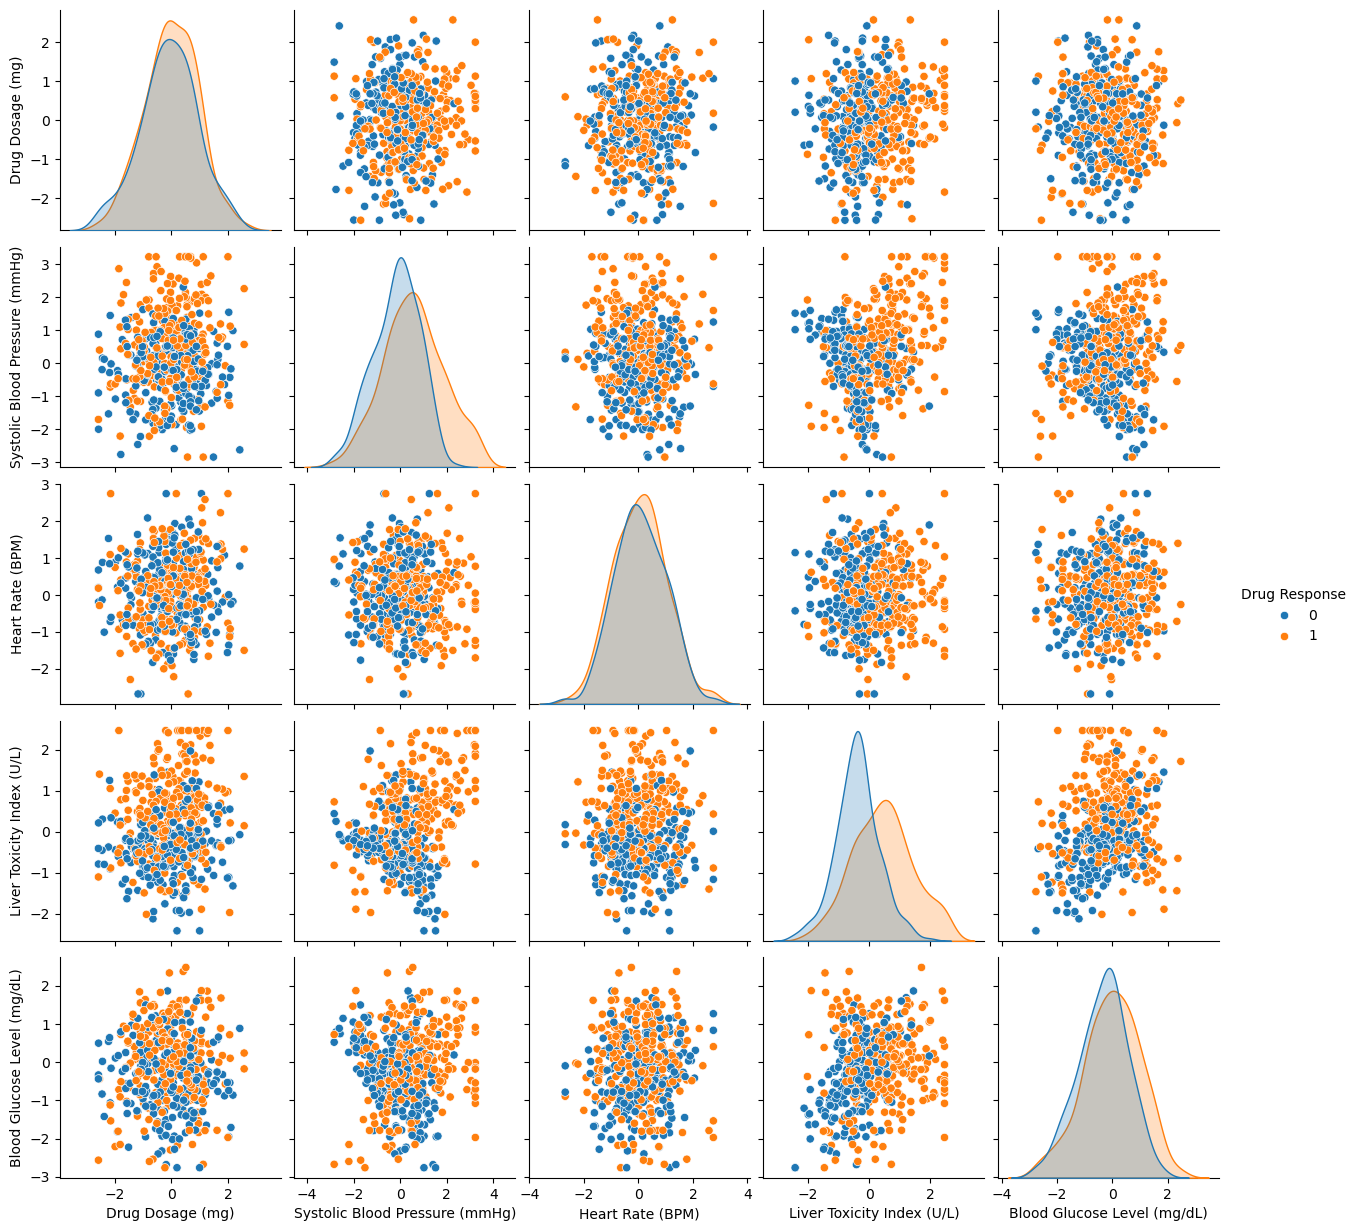

In [40]:
sns.pairplot(df, hue="Drug Response")
plt.show()

In [13]:
#### RBF kernel implementaion
svc= SVC(C=1,kernel='rbf')
svc.fit(X_train_scaled,y_train)
y_pred= svc.predict(X_test_scaled)

In [12]:
# accuracy score for RBF kernel with C=1
accuracy_score(y_test,y_pred)

0.71

In [51]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        48
           1       0.73      0.71      0.72        52

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100



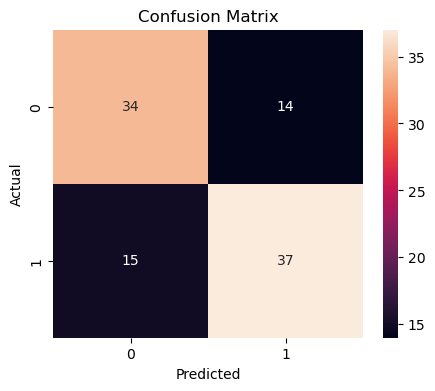

In [14]:
# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

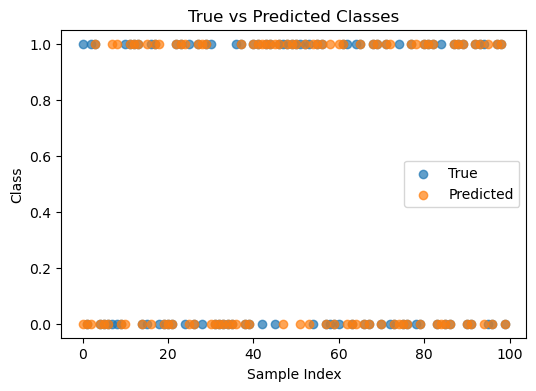

In [52]:
plt.figure(figsize=(6,4))
plt.scatter(range(len(y_test)), y_test, label="True", alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)
plt.title("True vs Predicted Classes")
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.legend()
plt.show()

Task 6: Parameter Tuning and Optimization

In [61]:
#### RBF kernel with regularization coefficient =95
svc= SVC(C=95,kernel='rbf')
svc.fit(X_train_scaled,y_train)
y_pred= svc.predict(X_test_scaled)
accuracy_score(y_test,y_pred)

0.79

In [62]:
# Linear kernel
svc= SVC(C=1,kernel='linear')
svc.fit(X_train_scaled,y_train)
y_pred= svc.predict(X_test_scaled)
accuracy_score(y_test,y_pred)

0.63

In [65]:
# Poly kernel
svc= SVC(C=1,kernel='poly')
svc.fit(X_train_scaled,y_train)
y_pred= svc.predict(X_test_scaled)
accuracy_score(y_test,y_pred)

0.69

In [66]:
#Sigmoid kernel
svc= SVC(C=1,kernel='sigmoid')
svc.fit(X_train_scaled,y_train)
y_pred= svc.predict(X_test_scaled)
accuracy_score(y_test,y_pred)

0.61